# DECISION TREE

## Objective:

In [1]:
## ● The objective of this assignment is to apply Decision Tree Classification to a given dataset, analyse the performance of the model, and interpret the results.

## Tasks:

### 1. Data Preparation:

In [2]:
## ● Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).

In [3]:
## Import required libraries.. 
import pandas as pd
import numpy as np

In [4]:
## Load and display the dataset..
df = pd.read_excel("heart_disease.xlsx")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


### 2. Exploratory Data Analysis (EDA):

In [5]:
## ● Perform exploratory data analysis to understand the structure of the dataset.
## ● Check for missing values, outliers, and inconsistencies in the data.
## ● Visualize the distribution of features, including histograms, box plots, and correlation matrices.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [7]:
## Total rows 908.. round 62 missing values can be seen in 'oldpeak'..
## All three types of datatypes can be seen the dataset (int, object and bool).. 

In [8]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [9]:
## If we look at df.describe(), all the numerical columns are almost normal..

## If we check the mean and median of each columns, they are almost equal with slight ups  and downs.. 
## Except oldpeak in which mean is significantly greater that meadian (considering the range of the column)..
## Mean slight less than median for (age, chol, thalch) indicating slight left skewness (negative)
## Mean slight greater than median for (trestbps, num) indicating slight right skewness (positive)

## If we check Q1 nd Q3 quartile distance with median.. 
## Its almost equal for age, trestbps(slighty greater Q3->median distance), chol, thalch, num..
## Thats an overview of structure of this dataset..

## All these interpretation are just an rough estimated idea, not an absolute result..

In [10]:
## 'oldpeak' has few missing values in it.. looking at the df.describe()..
## Mean is greater that median, also distance from (Q1->median) is less than (Q3->median).. 
## By looking at these figures we can confidently say that 'oldpeak' is right skewed (positive).. 

## Also for a column which is skewed, the best way to impute values in place of missing values is through 'median'..
df['oldpeak'] = df['oldpeak'].fillna(df['oldpeak'].median())

In [11]:
## Again checking for null values..
df.info()
print(df.isnull().sum())
## Missing values in column oldpeak were successfull dealt with.. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   908 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

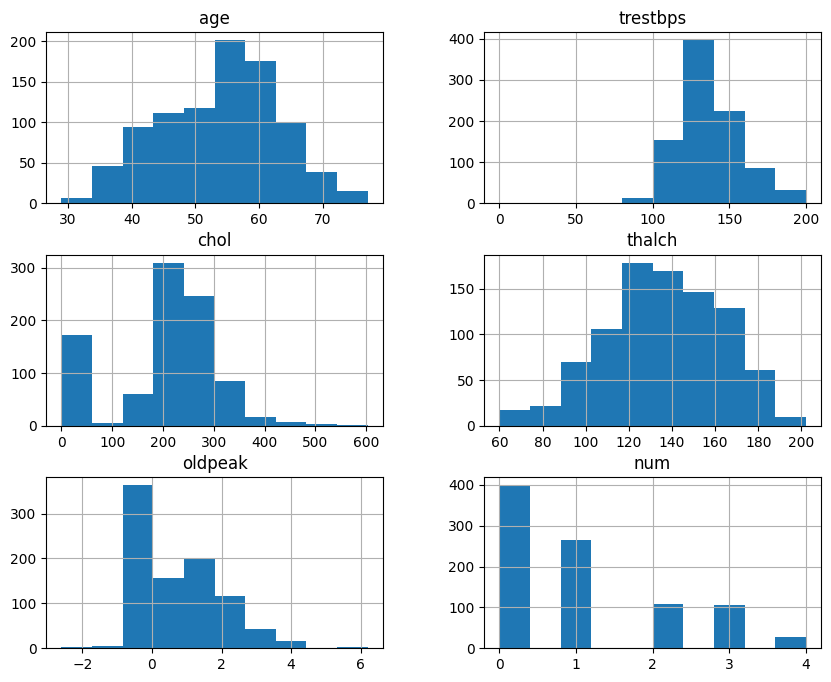

In [12]:
## Distributions of features (Histogram)
import matplotlib.pyplot as plt

df.hist(figsize = (10, 8))
plt.show

In [13]:
## 'Age' is almost roughly normally distributed.. most values are between 40 and 65.. no major skew can be seen.. it is a good feature..
## 'trestbps' is kind of right skewed.. most values are between 120 and 150.. seems like presence of few high values which could be possible mild ouliers..
## 'chol' is kind of right skewed.. its spread is quite wide (0-600).. some extreme data points can be seen, potential outliers..
## 'thalch' (max heart rate) also has almost normal distribution.. most of the values are centered between 130-160 .. its a good feature..
## 'oldpeak' has clear right skewness in distribution.. a good amount of datapoints are around 0.. few larger vlues arount 6 can also be seen (potential outliers)..
## 'num' is a discreate feature.. class imbalace is there ..

## Overall the hist plot shows that age and thalch follows approximate normal distribution..
## Features like chol and oldpeak are right skewed with potential outliers..
## The target variable 'num' is imbalanced with fewer instances in higher disease stages..

In [14]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak', 'slope', 'thal', 'num'],
      dtype='object')

In [15]:
## select numerical columns only 
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

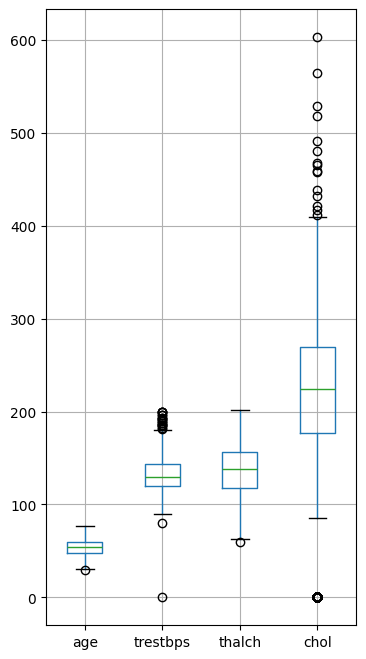

In [16]:
## Boxplot for outlier detection..

## Lets club features with similar scale together so that feature with least scale does not get suppresed among other.. 
## We will skip 'num' because its kind of categorical column in numeric datatype (0-4), with 5 categories.. boxpolt is meaningful for continious data only.. 
df[['age', 'trestbps', 'thalch', 'chol']].boxplot(figsize =(4, 8))
plt.show()

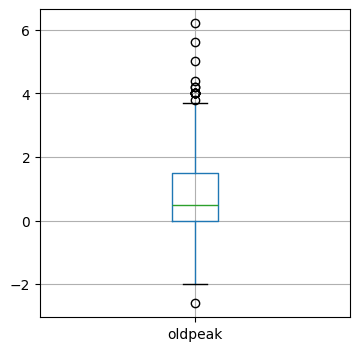

In [17]:
df[['oldpeak']].boxplot(figsize =(4, 4))
plt.show()

In [18]:
## Lets calculate IQR and other related statistics to outliers..
import seaborn as sns
for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    min_val = df[i].min()
    max_val = df[i].max()

    ## detect outliers..
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)][i]

    print(f"\nColumn: {i}")
    print(f"Q1 : {Q1}")
    print(f"Q3 : {Q3}")
    print(f"IQR : {IQR}")
    print(f"Lower Bound : {lower_bound}")
    print(f"Upper Bound : {upper_bound}")
    print(f"Minimum Value : {min_val}")
    print(f"Maximum Value : {max_val}")
    print(f"Potential Outiers : {len(outliers)}")
##    if len(outliers) > 0:
##        print("Potential Outliers:")
##        print(outliers.values)
    
##    plt.figure(figsize = (7, 2))
##    plt.boxplot(df[i].dropna(), vert = False)
##    plt.title(f"Boxplot of {i}")
##    plt.show()
    print("*"*100)


Column: age
Q1 : 47.75
Q3 : 60.0
IQR : 12.25
Lower Bound : 29.375
Upper Bound : 78.375
Minimum Value : 29
Maximum Value : 77
Potential Outiers : 1
****************************************************************************************************

Column: trestbps
Q1 : 120.0
Q3 : 144.0
IQR : 24.0
Lower Bound : 84.0
Upper Bound : 180.0
Minimum Value : 0
Maximum Value : 200
Potential Outiers : 22
****************************************************************************************************

Column: chol
Q1 : 176.75
Q3 : 270.0
IQR : 93.25
Lower Bound : 36.875
Upper Bound : 409.875
Minimum Value : 0
Maximum Value : 603
Potential Outiers : 187
****************************************************************************************************

Column: thalch
Q1 : 118.0
Q3 : 156.0
IQR : 38.0
Lower Bound : 61.0
Upper Bound : 213.0
Minimum Value : 60
Maximum Value : 202
Potential Outiers : 1
***********************************************************************************************

In [19]:
## chol has few outliers but other than that it is mostly a clean feature..
## For trestbps (blood pressure), some outliers can be seen on both side of whiskers.. most the outliers are toward upper whisker.. 
## thalch (heart rate).. few outliers toward lower whisker.. no too much concerning..
## chol (cholesterol).. they have quite a number of outliers toward upper whisker.. many points above 400-600 though mean is around 230.. hence presence of strong outliers can be seen..
## oldpeak .. clear outiers can be seen toward upper whiskers, some toward lower whisker as well.. even median is toward lower quartile(25 percentile), hence it is clearly right skewed.. 

## Overall we can say that some features like chol and oldpeak contain significant outliers while trestbps has moderate outliers.. 
## Features like age and thalch are relatively clean with minimal outliers.. 

In [20]:
## Although low to moderate outliers are present in some columns but we need not to strictly remove them..
## Because decision tree models are less affected by outliers.. hence no aggresive outlier removal treatment is required.. 

In [21]:
## correlation matrix..
import seaborn as sns

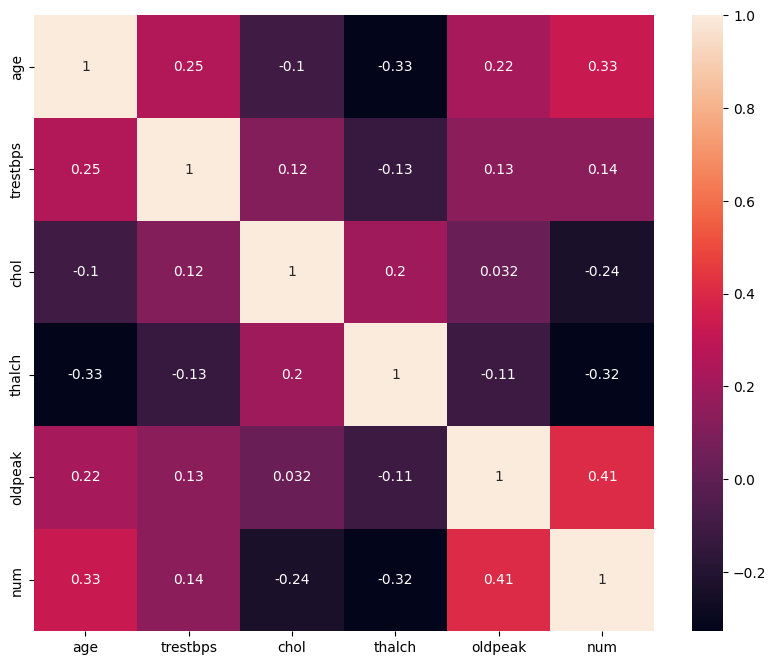

In [22]:
plt.figure(figsize = (10, 8))
sns.heatmap(df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num']].corr(), annot = True)
plt.show()

In [23]:
## The correlation matrix  reveals that most features have weak to moderate relationship with target variable (num)..
## Among all the features, oldpeak shows the strongest positive correlation (0.41) with the presence of heart disease.. 
## Which means oldpeak is directly proportional to heart disease.. 
## Age also has a moderate positive reelationship (0.33) with target variable.. means older people are more likely to have heart disease..
## On the other hand thalch  has negative correlation (-0.32) which means people with higher heart rates are less likely to have heart disease..
## Other features like chol and trestbps show only weak relationship with the target variable.. 


## Looking at the relationships between features, age and thalch have a negative correlation (-0.33) meaning as age increases maximum heart rate decreases..
## Age and trestbps have a slight positive relationship (0.25) which means blood pressure slightly increases with the age..
## Rest of the feature relationships are quite weak comparitively..

## Overall even though many correlations are weak, decision tree models can still capture  important patterns from the data, including nonlinear relationships..

### 3. Feature Engineering:

In [24]:
## ● If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features, or handling missing values.

In [25]:
df['num'].value_counts()

num
0    399
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [26]:
## Since 'num' is the target variable and there are 5 categories which can be seen (0,1,2,3,4).. 
## 0 --> no disease.. (1,2,3,4)--> stages of heart disease.. 
## Its better if we covert this column into binary category form (with 2 categories)..
## Why? because it will make the problem simple.. target variable will be converted into 2 categories (disease and no disease)..
## As we can see that there is a big class imbalance in the target variable (num).. this leads to poor model performance.. 
## This problem will also be eliminated if we combine (1,2,3,4) into one category.. 0 --> no disease.. (1,2,3,4)--> disease..
## Model will become simpler and stable.. 
## Also our task is to evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC)..
## These evaluations are easiers and cleaner in binary classification..


## Also if i want to, i can keep building the model and complete all the task by keeping 5 different categories in target variable..
## But choosing other way around..

In [27]:
## lets convert target variable in binary form..
df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df['num'].value_counts()

num
1    509
0    399
Name: count, dtype: int64

In [28]:
## After conversion the target variable is still kind of imbalanced but it definitely better than before..
## We can consider it as fairly balenced..

In [29]:
## Storing categorical columns.. 
cat_cols = df.select_dtypes(include = ['object'])

In [30]:
for i in cat_cols:
    print(i, df[i].nunique())

sex 2
cp 4
restecg 3
exang 4
slope 3
thal 3


In [31]:
## All categorical coumns have small number of categories (less than = 4)..
## These are kind of nominal categorical variable with no strong ordering, just labels..

In [32]:
## Lets apply one hot encoding to categorical variables..
print("Shape of the dataframe before encoding:", df.shape)

df = pd.get_dummies(df, columns = ['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], drop_first = True)

print("Shape of the dataframe after encoding:", df.shape)

Shape of the dataframe before encoding: (908, 13)
Shape of the dataframe after encoding: (908, 20)


In [33]:
df.columns

## Columns increased, categorical variables successfully converted..
## The dataset seems to be ready for model building..

Index(['age', 'trestbps', 'chol', 'fbs', 'thalch', 'oldpeak', 'num',
       'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'exang_FALSE', 'exang_TURE', 'slope_flat', 'slope_upsloping',
       'thal_normal', 'thal_reversable defect'],
      dtype='object')

In [34]:
df.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,True,150,2.3,0,True,False,False,True,False,False,False,False,False,False,False,False,False
1,41,135,203,False,132,0.0,0,True,True,False,False,True,False,False,False,False,True,False,False,False
2,57,140,192,False,148,0.4,0,True,False,False,False,True,False,False,False,False,True,False,False,False
3,52,118,186,False,190,0.0,0,True,False,False,True,False,False,False,False,False,True,False,False,False
4,57,110,201,False,126,1.5,0,True,False,False,False,True,False,True,False,False,True,False,False,False


In [35]:
## We can see that numerical columns are still in different scales.. these can rEsily be dealt with using scaling techniques..
## But in case of decision tree it is not required.. 
## Because decision tree works on splitting rules not on distance..hence scaling is not neccessarry..

## Also we can see that the encoded variable are in the form of True/ False..
## Model will  work with True/False.. 
## Its not necessary but its better to convert them into 1/0 form.. it will keep the clean, consistent and easy to interpret..

In [36]:
## Boolean to int..
df = df.astype(int)

In [37]:
df.dtypes

age                         int64
trestbps                    int64
chol                        int64
fbs                         int64
thalch                      int64
oldpeak                     int64
num                         int64
sex_Male                    int64
cp_atypical angina          int64
cp_non-anginal              int64
cp_typical angina           int64
restecg_normal              int64
restecg_st-t abnormality    int64
exang_True                  int64
exang_FALSE                 int64
exang_TURE                  int64
slope_flat                  int64
slope_upsloping             int64
thal_normal                 int64
thal_reversable defect      int64
dtype: object

In [38]:
## Now the whole dataframe has been succesfully converted into integer form.. it is ready for training phase..

### 4. Decision Tree Classification:

In [39]:
## ● - Split the dataset into training and testing sets (e.g., using an 80-20 split).
## ● - Implement a Decision Tree Classification model using a library like scikit-learn.
## ● - Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics 
## ● - (e.g., accuracy, precision, recall, F1-score, ROC-AUC).

In [40]:
## train test split..
## Now we will seperate features (X) and target (Y)..and split into training and testing data..
from sklearn.model_selection import train_test_split
X = df.drop('num', axis = 1)
Y = df['num']

X_train, X_test , Y_train,  Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [41]:
X_train.shape, X_test.shape
## Succesfully splitted the data for training..

((726, 19), (182, 19))

In [42]:
## Decision tree - model building..
## Since it is an classification problem so we need to import DecisionTreeClassifier..
from sklearn.tree import DecisionTreeClassifier

In [43]:
dt = DecisionTreeClassifier(random_state = 42)
dt.fit(X_train, Y_train) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [44]:
## Accuracy check
dt.score(X_test, Y_test)

0.7417582417582418

In [45]:
## The accuracy that we got is around 0.74 (74%)..
## Model is performimng decently..as a basic decision tree its not bad..
## But definitely it can be improved..

In [46]:
## Model evaluation..
from sklearn.metrics import classification_report, confusion_matrix

Y_pred = dt.predict(X_test)

In [47]:
## Using classification report we can find precision, recall f1-score at once..
print(confusion_matrix(Y_test, Y_pred))
print(classification_report(Y_test, Y_pred))

[[67 22]
 [25 68]]
              precision    recall  f1-score   support

           0       0.73      0.75      0.74        89
           1       0.76      0.73      0.74        93

    accuracy                           0.74       182
   macro avg       0.74      0.74      0.74       182
weighted avg       0.74      0.74      0.74       182



In [48]:
## The confusion matrix shows that the model correctly predicted 67 instances of class 0 (no disease)..
## aand 68 instances of class  (disease).. 
## However it misclassified 22 instances of class 0 as class 1 and 
## 25 instances of class 1 as class 0.. 
## This shows that the model is making a reasonable number of correct predictions but still has some errors in classification..

## From the classification report both classes have similar performance.. 
## For class 0 the precision is 0.73 and recall is 0.75 while for class 1 precision is 0.76 and recall is 0.73..
## The f1-score for both classes is around 0.74 which shows a balanced performance between precision and recall..
## The overall accuracy of the model is 74% indicating that the model is performing reasonably well on the test data..

## Overall the model shows balanced performance across both classes without strong bias toward any one class..
## but there is still room for improvement..

### 5. Hyperparameter Tuning:

In [49]:
## ● - Perform hyperparameter tuning to optimize the Decision Tree model.
## ● - Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.

In [50]:
## tune max_depth
dt2 = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dt2.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [51]:
## accuracy check
dt2.score(X_test, Y_test)

0.7637362637362637

In [52]:
## Accuracy increased from 0.74 to 0.76..
## It means limiting depth reduced overfitting.. model became more generalised..
## Lets try another max_depth
dt3 = DecisionTreeClassifier(max_depth = 5, random_state = 42)
dt3.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [53]:
dt3.score(X_test, Y_test)

0.7527472527472527

In [54]:
## Reducing the depth to 3 improved the model performance while increasing it to 5 slightly reduced accuracy..
## This indicates that a smaller depth helps prevent overfitting and improves generalisation..
## Lets try max_depth = 4 before moving forward to minimum sample split..
dt4 = DecisionTreeClassifier(max_depth = 4, random_state = 42)
dt4.fit(X_train, Y_train)
dt4.score(X_test, Y_test)

0.7857142857142857

In [55]:
## The best performance is achieved at max_depth = 4 with an accuracy of approximately 78.6% ..
## This idicates an optimal balance between underfitting and overfitting..

In [56]:
## min_samples_split..
dt5 = DecisionTreeClassifier(max_depth = 4, min_samples_split = 10, random_state = 42)
dt5.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [57]:
## Accuracy test
dt5.score(X_test, Y_test)

0.7857142857142857

In [58]:
## The accuracy is exactly same as model dt4.. 
## even i tried changing the value of min samsple split from 4 to 20, accuracy remained same for all the values..
## This shows that the model performance is not sensitive to this parameter ..
## Splits are already happening at sufficient sample size..
## The primary control over model complexity is governed by max_depth.. 

In [59]:
## Now lets try to tune the model using criterion..
dt6 = DecisionTreeClassifier(max_depth = 4, criterion = 'log_loss', random_state = 42)
dt6.fit(X_train, Y_train)
dt6.score(X_test, Y_test)

0.7692307692307693

In [60]:
## Among the different criteria tested, the 'gini' criterion provided the best performance..
## The 'entropy and 'log_loss' criteria showed slightly lower results..
## Hence the best configuration for our final model should be max_depth = 4, criterion = 'gini' (default) and default min_sample_split
## Best achieved model accuracy = 78.5%

### 6. Model Evaluation and Analysis:

In [61]:
## ● - Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
## ● - Visualize the decision tree structure to understand the rules learned by the model and identify important features

In [62]:
from sklearn.tree import plot_tree 

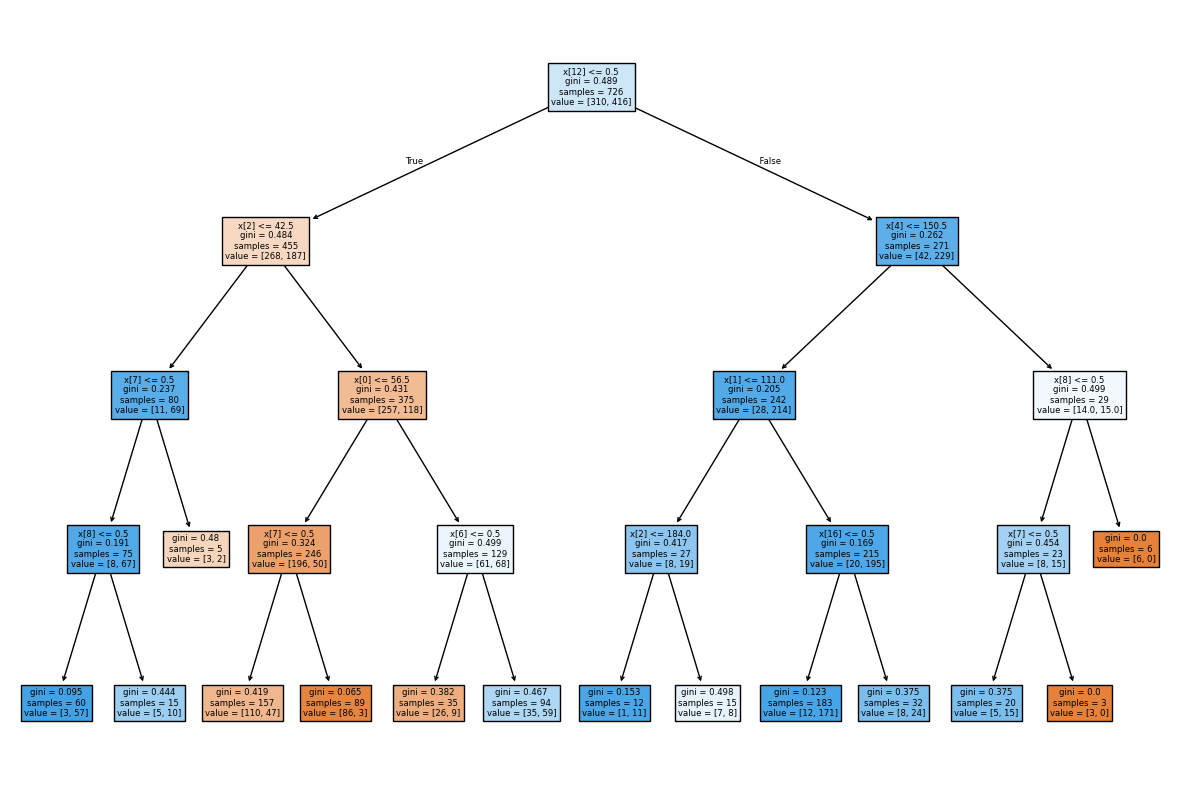

In [63]:
plt.figure(figsize = (15, 10))
plot_tree(dt5, filled = True)
plt.show()

In [64]:
## The decision tree shows how the model makes decision step by step based on different feature values..
## At the top node(root), the data is split based on one important feature , which divides the dataset into two groups.. 
## Each further split is based on condition like "feature <= value" helping model seperate patients with and without heart disease..

## The color indicates the predicted class, where one color represents no disease and the other represents diseases..
## Darker shades show more confident predictions..
## As we move down the tree the data becomes more pure.. means model is more certain about its predictions in those nodes..

## Overall the tree structure helps us understand which features are important and how different conditions lead to the final prediction..
## It also shows that the model is making decisions in a logical rule based manner.. 

### Interview Questions:

In [65]:
## ● - 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
## ● - 2. What is the difference between the Label encoding and One-hot encoding?

In [66]:
## Decision tree models have several hyperparameters that control how the tree is buit and how complex it becomes..
## One important parameter is max_depth, which limits how deep the tree can grow..
## If the depth is too high the model may overfit and miss important patterns..
## If it is too low the model may underfit and miss important patterns..

## Anothers important parameter is min_samples_split, which defines the minimum number of sample required to split the a node..
## Higher values make the model more general and reduce overfitting while lower values allow more splits and can increase complexity..

## The criterion parameters decides  how the quality of a split is measured such as gini or entropy or log_loss..
## Although the difference is usually small but it can slightly affect the model..

## overall these hypermeters helps control the balance between overfitting and underfitting and tuning them improves the model performance..

In [67]:
## Label encoding and one hot encoding are techniques used to convert categorical data into numerical form..

## In label encoding eacxh category is assigned a unique number..
## for example (low, medium, high)--> (0,1,2)..
## This method is simple but can create a false sense of order among categories.. 

## In one hot encoding, each category is converted into seperate column with binary values (0, 1)..
## For example a column with three categories will be converted into three new columns..
## This method does not introduce any order and is more suitable for nominal..

## The main difference is that label encoding uses a single column with numeric labels..
## while one hot encoding creates multiple columns to represent each category independently.. 

In [68]:
## Final conclusion

## The targetvariable was reasonably balanced, with 509 records belonging to the disease class and 399 to no disease class..
## Therefore accuracy was considered an appropriate metric for evaluating the model..

## A deceison tree classifier was trained and optimized using hyperparameter tuning. 
## Different values of parameter such as max_depth, minimum samples split, and criterion were tested to improve model performance and reduce overfitting..

## The final tuned Decision tree model achieved an accuracy of 79% on the test data..
## The result indicates that the model was able to correctly classify approximately 79 out of every 100 instances. 
## Sincethe baseline accuracy obtained by predicting only the majority class would be around 56%, the model showed a significant improvement and demonstrated good predictive performance. 

## Overall the tuned Decision tree model performed well and was effective in identifying whetaher a patient had the disease or not.. 